In [1]:
%pip install seaborn

In [2]:
from pyodide.http import pyfetch
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<ipython-input-2-6a3d8cf0d22a>:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
pd.set_option("display.max_columns", None)

In [4]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"

In [5]:
async def download(url, filename):
        response = await pyfetch(url)
        print(response.status)
        if response.status == 200:
            with open (filename, "wb") as f:
                f.write(await response.bytes())
                print(f"{filename} downloaded successfully")

In [6]:
await download(url,"automobile_eda.csv")

200
automobile_eda.csv downloaded successfully


In [7]:
df = pd.read_csv("automobile_eda.csv")
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,0.890278,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,0.890278,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,0.909722,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,0.919444,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,0.922222,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   aspiration         201 non-null    object 
 4   num-of-doors       201 non-null    object 
 5   body-style         201 non-null    object 
 6   drive-wheels       201 non-null    object 
 7   engine-location    201 non-null    object 
 8   wheel-base         201 non-null    float64
 9   length             201 non-null    float64
 10  width              201 non-null    float64
 11  height             201 non-null    float64
 12  curb-weight        201 non-null    int64  
 13  engine-type        201 non-null    object 
 14  num-of-cylinders   201 non-null    object 
 15  engine-size        201 non-null    int64  
 16  fuel-system        201 non

In [9]:
df.describe(include = "all")

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
count,201.000000,201.00000,201,201,201,201,201,201,201.000000,201.000000,201.000000,201.000000,201.000000,201,201,201.000000,201,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,200,201.000000,201.000000
unique,NaN,NaN,22,2,2,5,3,2,NaN,NaN,NaN,NaN,NaN,6,7,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,toyota,std,four,sedan,fwd,front,NaN,NaN,NaN,NaN,NaN,ohc,four,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,NaN,NaN,32,165,115,94,118,198,NaN,NaN,NaN,NaN,NaN,145,157,NaN,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115,NaN,NaN
mean,0.840796,122.00000,NaN,NaN,NaN,NaN,NaN,NaN,98.797015,0.837102,0.915126,53.766667,2555.666667,NaN,NaN,126.875622,NaN,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,NaN,0.099502,0.900498
std,1.254802,31.99625,NaN,NaN,NaN,NaN,NaN,NaN,6.066366,0.059213,0.029187,2.447822,517.296727,NaN,NaN,41.546834,NaN,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,NaN,0.300083,0.300083
min,-2.000000,65.00000,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,0.678039,0.837500,47.800000,1488.000000,NaN,NaN,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,NaN,0.000000,0.000000
25%,0.000000,101.00000,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,0.801538,0.890278,52.000000,2169.000000,NaN,NaN,98.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,NaN,0.000000,1.000000
50%,1.000000,122.00000,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,0.832292,0.909722,54.100000,2414.000000,NaN,NaN,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,NaN,0.000000,1.000000
75%,2.000000,137.00000,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,0.881788,0.925000,55.500000,2926.000000,NaN,NaN,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,NaN,0.000000,1.000000


In [10]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               4
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    1
diesel               0
gas                  0
dtype: int64

In [11]:
mean_stroke = df["stroke"].mean()
df["stroke"] = df["stroke"].fillna(mean_stroke)

In [12]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    1
diesel               0
gas                  0
dtype: int64

<h3>Exploratory analysis</h3>
<h6>Correlations betweent numerical data</h6>

In [13]:
df_numerical_data = df.select_dtypes(include = ["int","float"])
df_numerical_data.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,0,1
1,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,0,1
2,1,122,94.5,0.822681,0.909722,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,0,1
3,2,164,99.8,0.848630,0.919444,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,0,1
4,2,164,99.4,0.848630,0.922222,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,0,1


In [14]:
df_numerical_data.corr().head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.007992,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055127,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.157964,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.123913,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188814,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356


In [15]:
df[["bore", "stroke", "compression-ratio","horsepower"]].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566936
stroke,-0.055390,1.000000,0.187854,0.098282
compression-ratio,0.001263,0.187854,1.000000,-0.214514
horsepower,0.566936,0.098282,-0.214514,1.000000


<h5>Scatter plots:</h5>

(0.0, 339.25)

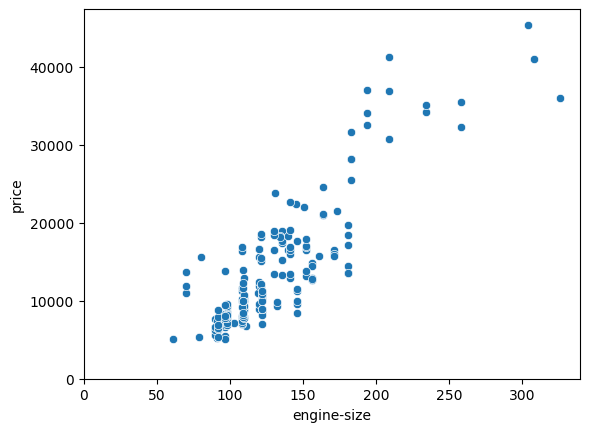

In [16]:
sns.scatterplot(x = "engine-size", y = "price", data = df)
plt.ylim(0,)
plt.xlim(0,)

(0.0, 339.25)

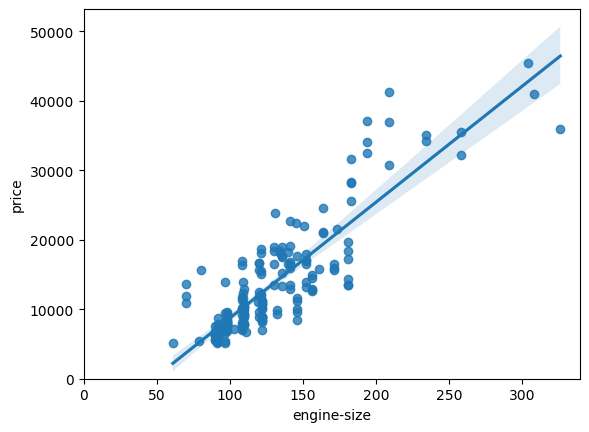

In [17]:
sns.regplot(x = "engine-size", y = "price", data = df)
plt.ylim(0,)
plt.xlim(0,)

In [18]:
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


(0.0, 48189.854044054075)

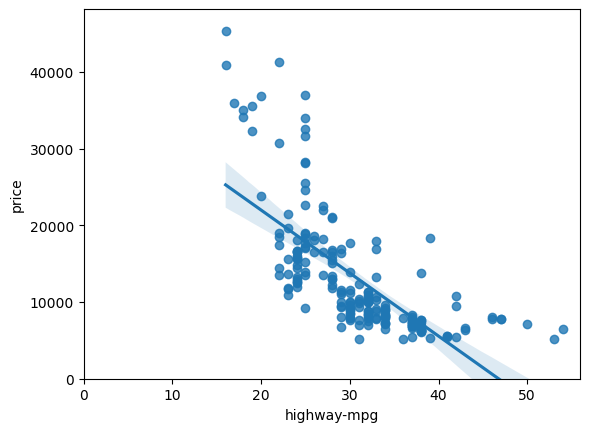

In [19]:
sns.regplot(x = "highway-mpg", y= "price", data = df)
plt.xlim(0,)
plt.ylim(0,)

In [20]:
df[["highway-mpg","price"]].corr()

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


In [21]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


(0.0, 47414.1)

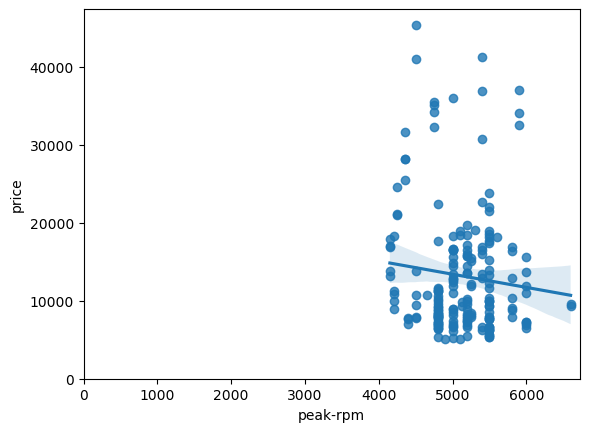

In [22]:
sns.regplot(x = "peak-rpm", y = "price", data = df)
plt.xlim(0,)
plt.ylim(0,)

(0.0, 47414.1)

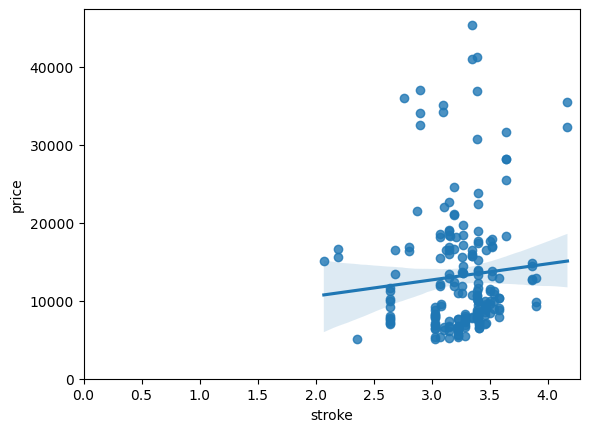

In [23]:
sns.regplot(x = "stroke", y = "price" , data = df)
plt.xlim(0,)
plt.ylim(0,)

In [24]:
df[["stroke","price"]].corr()

,stroke,price
stroke,1.000000,0.082267
price,0.082267,1.000000


<h5>Categorical data:</h5>
<p>Boxplots</p>

<AxesSubplot:xlabel='body-style', ylabel='price'>

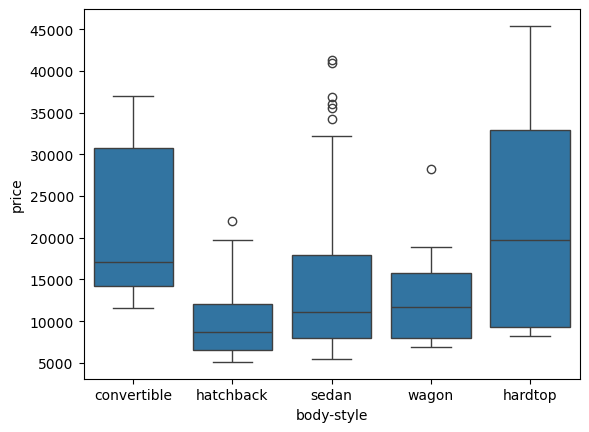

In [25]:
sns.boxplot(x ="body-style",y="price", data = df)

<AxesSubplot:xlabel='engine-location', ylabel='price'>

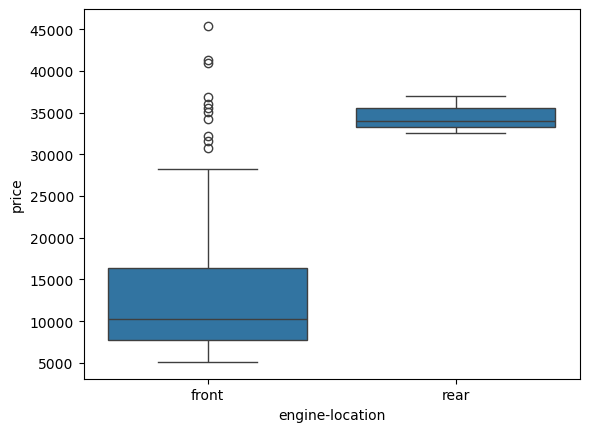

In [26]:
sns.boxplot(x = "engine-location", y = "price", data = df)

<AxesSubplot:xlabel='drive-wheels', ylabel='price'>

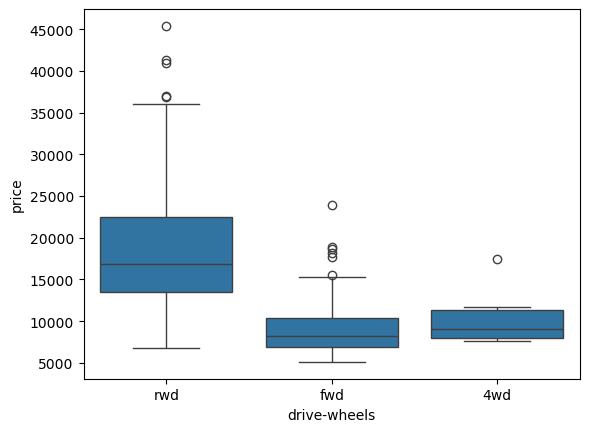

In [27]:
sns.boxplot(x = "drive-wheels", y = "price", data = df)

<h3>Descriptive statistics</h3>

In [28]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.316048,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


In [29]:
df.describe(include = ["object"])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


<h5>Value counts as dataframes</h5>
<p>Drive wheel data</p>

In [30]:
df["drive-wheels"].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

In [31]:
df_drive_wheels = df["drive-wheels"].value_counts().to_frame()
df_drive_wheels.reset_index(inplace= True)
df_drive_wheels.rename(columns={"drive-wheels":"value count"}, inplace=True)
df_drive_wheels.index.name= "drive-wheels"
df_drive_wheels

,value count,count
drive-wheels,,
0,fwd,118
1,rwd,75
2,4wd,8


<h4>Value counts as dataframes</h4>
<p>engine location</p>

In [32]:
df["engine-location"].value_counts()

engine-location
front    198
rear       3
Name: count, dtype: int64

In [33]:
df_engine_location = df["engine-location"].value_counts().to_frame()
df_engine_location.reset_index(inplace = True)
df_engine_location.rename(columns={"engine-location":"value count"}, inplace= True)
df_engine_location.index.name = "engine location"
df_engine_location 

,value count,count
engine location,,
0,front,198
1,rear,3


<h3>Grouping average</h3>

In [34]:
df["drive-wheels"].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

In [35]:
df_driveWheels_bodyStyle= df[["drive-wheels", "body-style", "price"]]
df_driveWheels_bodyStyle.head()


,drive-wheels,body-style,price
0,rwd,convertible,13495.0
1,rwd,convertible,16500.0
2,rwd,hatchback,16500.0
3,fwd,sedan,13950.0
4,4wd,sedan,17450.0


In [36]:
df_grouped_by_drive_wheels = df_driveWheels_bodyStyle.groupby(["drive-wheels"], as_index = False).agg({"price":"mean"}).round(2)
df_grouped_by_drive_wheels.head()

,drive-wheels,price
0,4wd,10241.00
1,fwd,9244.78
2,rwd,19757.61


<h5>Grouop by two categories </h5>

In [37]:
df_groupby_driveWheels_and_bodyStyle = df_driveWheels_bodyStyle.groupby(["drive-wheels","body-style"], as_index = False).agg({"price":"mean"}).round(2)
df_groupby_driveWheels_and_bodyStyle

,drive-wheels,body-style,price
0,4wd,hatchback,7603.00
1,4wd,sedan,12647.33
2,4wd,wagon,9095.75
3,fwd,convertible,11595.00
4,fwd,hardtop,8249.00
5,fwd,hatchback,8396.39
6,fwd,sedan,9811.80
7,fwd,wagon,9997.33
8,rwd,convertible,23949.60
9,rwd,hardtop,24202.71


<h3>Pivot table</h3>

In [38]:
group_pivot = df_groupby_driveWheels_and_bodyStyle.pivot(index = "drive-wheels", columns = "body-style")
group_pivot = group_pivot.fillna(0)
group_pivot

price                                        
body-style   convertible   hardtop hatchback     sedan     wagon
drive-wheels                                                    
4wd                  0.0      0.00   7603.00  12647.33   9095.75
fwd              11595.0   8249.00   8396.39   9811.80   9997.33
rwd              23949.6  24202.71  14337.78  21711.83  16994.22

<h3>Average price per body-style:</h3>

In [39]:
df_groupby_bodyStyle_price = df_driveWheels_bodyStyle.groupby(["body-style"], as_index = False).agg({"price":"mean"}).round(2)
df_groupby_bodyStyle_price

,body-style,price
0,convertible,21890.50
1,hardtop,22208.50
2,hatchback,9957.44
3,sedan,14459.76
4,wagon,12371.96


<h3>Heat map: relationship between body style and drive wheels</h3>

<AxesSubplot:xlabel='None-body-style', ylabel='drive-wheels'>

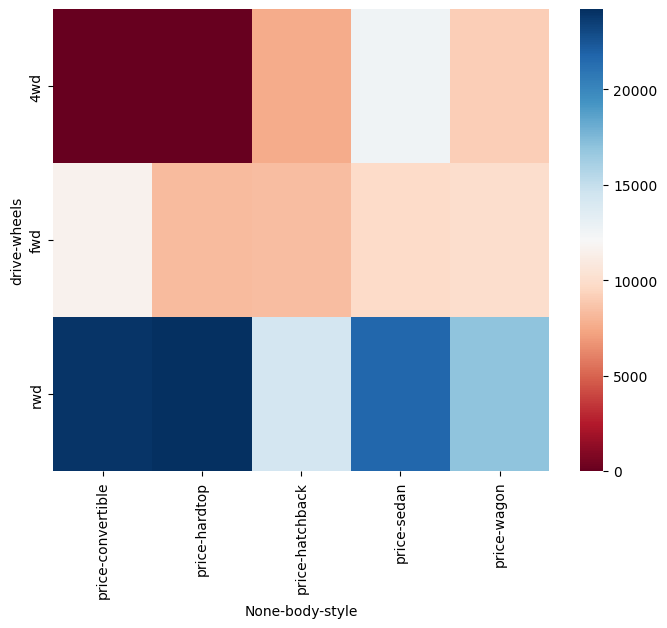

In [40]:
plt.figure(figsize=(8,6))
sns.heatmap(group_pivot, cmap = "RdBu", annot = False)

<h2>Correlations:</h2>

In [41]:
pearson_coef, p_value = stats.pearsonr(df["wheel-base"], df["price"])
print(f"pearson_coef = {pearson_coef:.2f}, p-value = {p_value:.3f}")

pearson_coef = 0.58, p-value = 0.000


(0.0, 47616.44610174312)

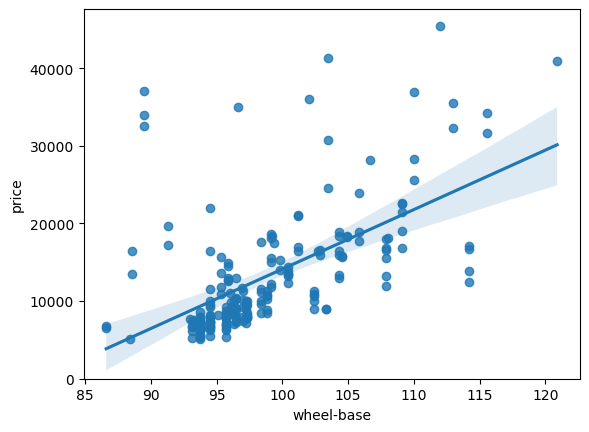

In [42]:
sns.regplot(x = "wheel-base", y = "price", data = df)
plt.ylim(0,)

In [43]:
pearson_coef, p_value = stats.pearsonr(df["wheel-base"], df["price"])
pearson_coef, p_value

(0.5846418222655085, 8.076488270732338e-20)

In [44]:
numeric_columns = df.select_dtypes(include = "number").columns
numeric_columns

Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'city-L/100km', 'diesel', 'gas'],
      dtype='object')

In [45]:
cols = ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'city-L/100km', 'diesel', 'gas']

for col in cols:
    
    pearson_coef, p_value = stats.pearsonr(df[col], df["price"])
    if p_value >.05:
        print(f"""Non significant association between {col} and price:
        r = {pearson_coef:.2f}, p-value = {p_value:.3f}, ns""")
    else:
         print(f"""Significant association between {col} and price:
         r = {pearson_coef:.2f}, p-value = {p_value:.3f}, sig""")

Non significant association between symboling and price:
        r = -0.08, p-value = 0.245, ns
Non significant association between normalized-losses and price:
        r = 0.13, p-value = 0.058, ns
Significant association between wheel-base and price:
         r = 0.58, p-value = 0.000, sig
Significant association between length and price:
         r = 0.69, p-value = 0.000, sig
Significant association between width and price:
         r = 0.75, p-value = 0.000, sig
Non significant association between height and price:
        r = 0.14, p-value = 0.055, ns
Significant association between curb-weight and price:
         r = 0.83, p-value = 0.000, sig
Significant association between engine-size and price:
         r = 0.87, p-value = 0.000, sig
Significant association between bore and price:
         r = 0.54, p-value = 0.000, sig
Non significant association between stroke and price:
        r = 0.08, p-value = 0.246, ns
Non significant association between compression-ratio and price:
 

In [48]:
from IPython.display import display, HTML

cols = ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'city-L/100km', 'diesel', 'gas']

results = []

for col in cols:
    pearson_coef, p_value = stats.pearsonr(df[col], df["price"])
    sig = "sig" if p_value <= .05 else "n.s"

    results.append({
        "Comparaison": f"{col} Vs price",
        "r" : f"{pearson_coef:.2f}",
        "p-value" : f"{p_value:.3f}, {sig}"
    })
df_results = pd.DataFrame(results)
display(HTML(df_results.to_html(index = True)))

,Comparaison,r,p-value
0,symboling Vs price,-0.08,"0.245, n.s"
1,normalized-losses Vs price,0.13,"0.058, n.s"
2,wheel-base Vs price,0.58,"0.000, sig"
3,length Vs price,0.69,"0.000, sig"
4,width Vs price,0.75,"0.000, sig"
5,height Vs price,0.14,"0.055, n.s"
6,curb-weight Vs price,0.83,"0.000, sig"
7,engine-size Vs price,0.87,"0.000, sig"
8,bore Vs price,0.54,"0.000, sig"
9,stroke Vs price,0.08,"0.246, n.s"


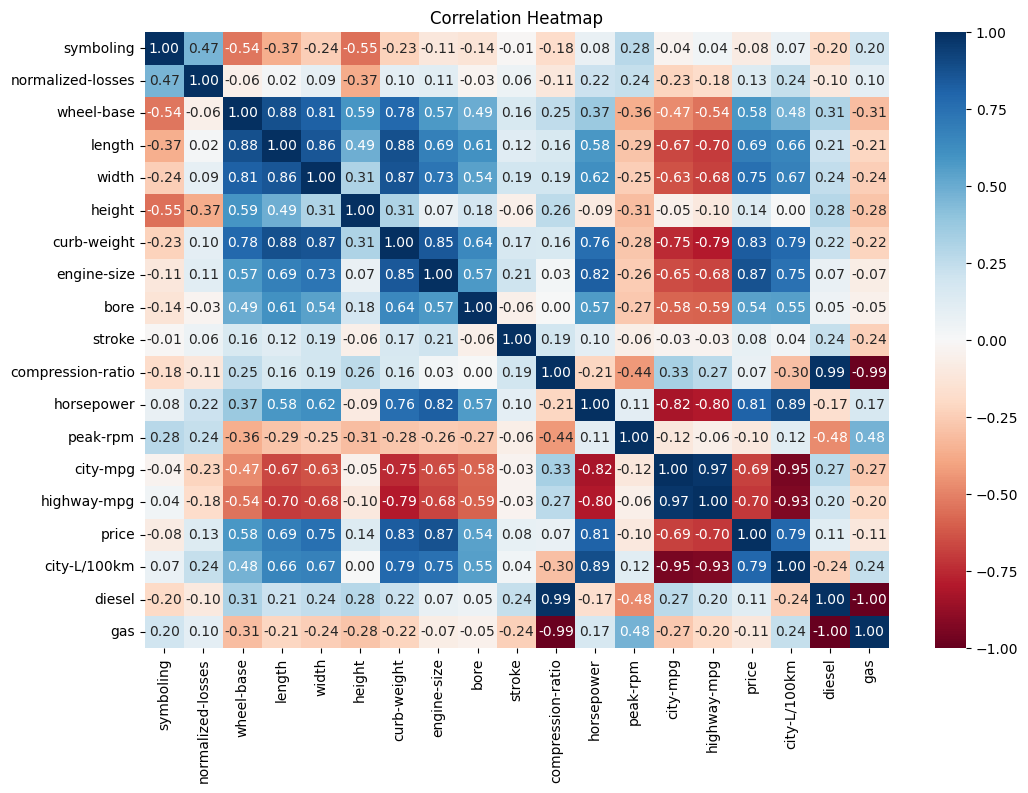

In [49]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="RdBu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()